In [ ]:
import pandas as pd
import joblib

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
import pandas as pd
# Load Dataset
data = pd.read_csv(
    r"/content/train_data.txt",
    sep=" ::: ", # Changed separator to ' ::: '
    engine="python", # 'engine="python"' is required for multi-character separators
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"]
)

In [ ]:
# Features
X = data["DESCRIPTION"]


In [ ]:
# Labels
y = data["GENRE"]

In [ ]:
# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Model
model = LogisticRegression(max_iter=1000)

In [ ]:
# Train
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Predict
y_pred = model.predict(X_test)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5788988287374343


In [ ]:
# Save
joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Model Saved")

Model Saved


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
# Features
X = data["DESCRIPTION"]

# Labels
y = data["GENRE"]

In [ ]:
# Convert Text into Numbers
vectorizer = TfidfVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Naive Bayes Model
model = MultinomialNB()


In [ ]:
# Train Model
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.445540901964401


In [ ]:
# Save Model
joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC


In [ ]:
# Features
X = data["DESCRIPTION"]

# Labels
y = data["GENRE"]

In [ ]:
# Convert Text to Numbers
vectorizer = TfidfVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

In [ ]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# SVM Model
model = LinearSVC()

# Train Model
model.fit(X_train, y_train)

LinearSVC()

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5838790002766762


In [ ]:
# Save Model
joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
models = {

    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Support Vector Machine": LinearSVC()
}


In [ ]:
accuracies = {}
for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    accuracies[name] = accuracy

    print("\n=========================")
    print(name)
    print("=========================")
    print("Accuracy:", accuracy)


Naive Bayes
Accuracy: 0.445540901964401

Logistic Regression
Accuracy: 0.5788988287374343

Support Vector Machine
Accuracy: 0.583971225675551


In [ ]:
algorithm_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

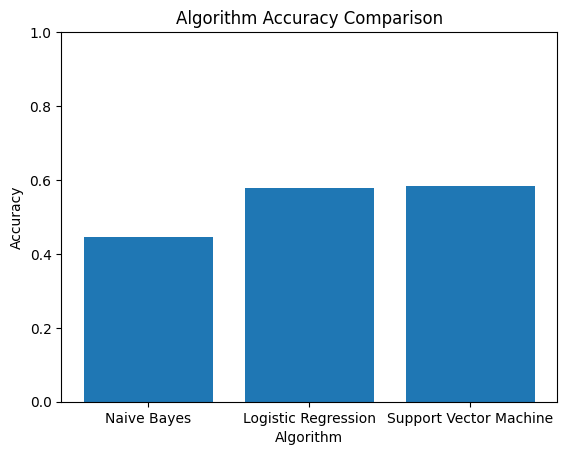

In [ ]:
plt.bar(algorithm_names, accuracy_values)
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.title("Algorithm Accuracy Comparison")
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.show()

In [ ]:
import gradio as gr
import joblib

# Load the trained model and vectorizer
model = joblib.load('model.pkl')
vectorizer = joblib.load('vectorizer.pkl')

def predict_genre(description):
    # Vectorize the input description
    description_vectorized = vectorizer.transform([description])
    # Predict the genre
    predicted_genre = model.predict(description_vectorized)[0]
    return predicted_genre

interface = gr.Interface(
    fn=predict_genre,
    inputs=gr.Textbox(
        lines=8,
        placeholder="Enter movie description here..."
    ),
    outputs="text",
    title="🎬 Movie Genre Classification",
    description="Enter a movie story and predict its genre.",
    theme="soft"
)

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d0ccf8cb3dc9ee92d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
